# 06. ALS 임베딩 탐색 & 케이스 스터디

05번에서 학습한 ALS 모델의 **잠재 벡터(embedding)**를 직접 꺼내봅니다.

1. **임베딩 유사도 분석**: openclaw, tensorflow, claude 관련 레포들이 잠재 공간에서 얼마나 가까운지
2. **2D 시각화**: t-SNE/UMAP으로 레포 임베딩 클러스터 확인
3. **케이스 스터디: DarkSword**: iOS 익스플로잇 체인 공개 사건의 GitHub 이벤트 분석

## 1. 데이터 & 모델 준비

In [1]:
import os
import subprocess
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import sparse
from implicit.als import AlternatingLeastSquares

from gharchive.client import create_client
from ghrec.recommend import load_period, popularity_scores

OUTPUT_DIR = Path("../../data/daily_agg")
MODEL_DIR = Path("../../data/models")
MODEL_DIR.mkdir(exist_ok=True)
KEY_PATH = os.environ.get("GCP_KEY_PATH", "../../gcp-key.json")

WEIGHTS = {
    "WatchEvent": 1.0,
    "ForkEvent": 2.0,
    "IssuesEvent": 0.5,
    "PullRequestEvent": 3.0,
    "IssueCommentEvent": 0.3,
    "PushEvent": 0.2,
}

# 최신 데이터 날짜 확인
parquet_files = sorted(OUTPUT_DIR.glob("*.parquet"))
latest_date = parquet_files[-1].stem
print(f"최신 데이터: {latest_date}")
print(f"파일 수: {len(parquet_files)}")

/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


최신 데이터: 20260328
파일 수: 42


In [2]:
# 학습 기간
TRAIN_END = date(int(latest_date[:4]), int(latest_date[4:6]), int(latest_date[6:8]))
TRAIN_START = date(2026, 3, 1)

df = load_period(OUTPUT_DIR, TRAIN_START, TRAIN_END)
print(f"기간: {TRAIN_START} ~ {TRAIN_END}")
print(f"전체 rows: {len(df):,}")
print(f"유저: {df['actor_id'].nunique():,}, 레포: {df['repo_id'].nunique():,}")

# 가중 점수 집계
df = df.copy()
df["score"] = df["type"].map(WEIGHTS).fillna(0) * df["cnt"]
feedback = df.groupby(["actor_id", "repo_id"])["score"].sum().reset_index()
feedback = feedback[feedback["score"] > 0]

print(f"Feedback: {len(feedback):,} (유저 {feedback['actor_id'].nunique():,}, 레포 {feedback['repo_id'].nunique():,})")

기간: 2026-03-01 ~ 2026-03-28
전체 rows: 39,013,569


유저: 6,280,082, 레포: 10,873,238


Feedback: 12,152,271 (유저 5,511,853, 레포 8,856,268)


In [3]:
# Sparse matrix 구축
all_user_ids = feedback["actor_id"].unique()
all_item_ids = feedback["repo_id"].unique()

user2idx = {uid: i for i, uid in enumerate(all_user_ids)}
item2idx = {iid: i for i, iid in enumerate(all_item_ids)}
idx2item = {i: iid for iid, i in item2idx.items()}
idx2user = {i: uid for uid, i in user2idx.items()}

row = feedback["actor_id"].map(user2idx).values
col = feedback["repo_id"].map(item2idx).values
data = feedback["score"].values.astype(np.float32)

train_sparse = sparse.csr_matrix(
    (data, (row, col)),
    shape=(len(all_user_ids), len(all_item_ids)),
)
print(f"Sparse: {train_sparse.shape[0]:,} × {train_sparse.shape[1]:,}, nnz={train_sparse.nnz:,}")

Sparse: 5,511,853 × 8,856,268, nnz=12,152,271


In [4]:
import pickle, time

ALS_PATH = MODEL_DIR / f"als_{latest_date}.pkl"
IDX_PATH = MODEL_DIR / f"idx_{latest_date}.pkl"

if ALS_PATH.exists():
    print(f"저장된 모델 로드: {ALS_PATH.name}")
    model = pickle.loads(ALS_PATH.read_bytes())
    idx_data = pickle.loads(IDX_PATH.read_bytes())
    user2idx, item2idx, idx2item, idx2user = (
        idx_data["user2idx"], idx_data["item2idx"],
        idx_data["idx2item"], idx_data["idx2user"],
    )
    # sparse matrix 재구축 (추천 시 필요)
    row = feedback["actor_id"].map(user2idx).values
    col = feedback["repo_id"].map(item2idx).values
    data = feedback["score"].values.astype(np.float32)
    train_sparse = sparse.csr_matrix(
        (data, (row, col)), shape=(len(user2idx), len(item2idx))
    )
else:
    print("ALS 학습 시작...")
    t0 = time.time()
    model = AlternatingLeastSquares(
        factors=64, regularization=0.01, iterations=15, random_state=42,
    )
    model.fit(train_sparse)
    elapsed = time.time() - t0
    print(f"학습 완료: {elapsed:.1f}s")

    # 저장
    ALS_PATH.write_bytes(pickle.dumps(model))
    IDX_PATH.write_bytes(pickle.dumps({
        "user2idx": user2idx, "item2idx": item2idx,
        "idx2item": idx2item, "idx2user": idx2user,
    }))
    print(f"모델 저장: {ALS_PATH.name} ({ALS_PATH.stat().st_size / 1024**2:.0f}MB)")

print(f"Item factors: {model.item_factors.shape}")
print(f"User factors: {model.user_factors.shape}")

ALS 학습 시작...


  0%|          | 0/15 [00:00<?, ?it/s]

  7%|▋         | 1/15 [00:23<05:31, 23.70s/it]

 13%|█▎        | 2/15 [00:44<04:49, 22.28s/it]

 20%|██        | 3/15 [01:05<04:18, 21.54s/it]

...

 93%|█████████▎| 14/15 [04:35<00:18, 18.28s/it]

100%|██████████| 15/15 [04:53<00:00, 18.21s/it]

100%|██████████| 15/15 [04:53<00:00, 19.60s/it]

학습 완료: 306.5s


모델 저장: als_20260328.pkl (3508MB)
Item factors: (8856268, 64)
User factors: (5511853, 64)


## 2. Repo 이름 매핑

임베딩을 탐색하려면 repo_id → repo_name 매핑이 필요합니다.

In [5]:
# 관심 repo 검색을 위해 BigQuery에서 이름 가져오기
client = create_client(KEY_PATH)

SEARCH_KEYWORDS = [
    "openclaw", "tensorflow", "claude", "anthropic",
    "pytorch", "darksword", "DarkSword",
    "langchain", "llama", "openai",
    "jarvis", "vue-quill",
]

keyword_conditions = " OR ".join(
    f"LOWER(repo.name) LIKE '%{kw.lower()}%'" for kw in SEARCH_KEYWORDS
)

name_query = f"""
SELECT DISTINCT repo.id AS repo_id, repo.name AS repo_name
FROM `githubarchive.day.{latest_date}`
WHERE {keyword_conditions}
"""

repo_names_df = client.query(name_query).to_dataframe()
print(f"키워드 매칭 repo: {len(repo_names_df):,}")

# 우리 item2idx에 있는 것만 필터
repo_names_df = repo_names_df[repo_names_df["repo_id"].isin(item2idx)]
name_map = dict(zip(repo_names_df["repo_id"], repo_names_df["repo_name"]))
print(f"임베딩에 존재하는 repo: {len(name_map):,}")

# 키워드별 개수
for kw in SEARCH_KEYWORDS:
    matched = [n for n in name_map.values() if kw.lower() in n.lower()]
    if matched:
        print(f"  {kw}: {len(matched)}개 (예: {matched[:3]})")

키워드 매칭 repo: 7,504


임베딩에 존재하는 repo: 6,812
  openclaw: 1756개 (예: ['Hans-Matrimony/openclawforaiastro', 'Bitplanet-L1/genie-openclaw', 'aileen5150/openclaw-lab'])
  tensorflow: 92개 (예: ['johnperez416/tensorflow', 'tensorflow/tensorflow', 'chickenandpork/tensorflow'])
  claude: 3234개 (예: ['hsol/claudeclaw-healthcheck', 'jsingason/dotclaude', 'Yeachan-Heo/oh-my-claudecode'])
  anthropic: 77개 (예: ['anthropics/claude-code-action', 'anthropics/claude-quickstarts', 'anthropics/claude-plugins-official'])
  pytorch: 226개 (예: ['AnkitYuva/meta-pytorch-hackathon', 'pytorch/alerting-infra', 'pytorch/pytorch'])
  darksword: 13개 (예: ['Explorer1092/darksword-kexploit', 'W1xced-io/darksword-kexploit', 'Darksword333/ilu3-ocaml'])
  DarkSword: 13개 (예: ['Explorer1092/darksword-kexploit', 'W1xced-io/darksword-kexploit', 'Darksword333/ilu3-ocaml'])
  langchain: 320개 (예: ['manyasachdeva27/Chains-in-langchain', 'langchain-ai/open-swe', 'michaelnchin/langchain-aws'])
  llama: 601개 (예: ['spiritbuun/llama-cpp-turboquant-cuda', 'Pudd

## 3. 임베딩 유사도 탐색

ALS가 학습한 item embedding(Q 행렬)에서 **코사인 유사도**로 유사 레포를 찾습니다.

In [6]:
from sklearn.metrics.pairwise import cosine_similarity


def find_similar_repos(repo_name_query, name_map, item2idx, model, top_k=10):
    """이름에 query가 포함된 repo를 찾고, 가장 유사한 repo top_k를 반환."""
    # query로 repo 찾기
    candidates = {
        rid: name for rid, name in name_map.items()
        if repo_name_query.lower() in name.lower()
    }
    if not candidates:
        print(f"'{repo_name_query}' 매칭 repo 없음")
        return None

    # 첫 번째 매칭 사용 (또는 가장 이름이 짧은 것 = 보통 메인 레포)
    target_rid = min(candidates, key=lambda r: len(candidates[r]))
    target_name = candidates[target_rid]
    target_idx = item2idx[target_rid]

    # 타겟 벡터
    target_vec = model.item_factors[target_idx].reshape(1, -1)

    # 전체 아이템과 유사도 계산
    all_item_vecs = model.item_factors
    sims = cosine_similarity(target_vec, all_item_vecs)[0]

    # Top-K (자기 자신 제외)
    top_indices = np.argsort(sims)[::-1][1:top_k + 1]

    results = []
    for idx in top_indices:
        rid = idx2item[idx]
        results.append({
            "repo_id": rid,
            "repo_name": name_map.get(rid, f"(id:{rid})"),
            "similarity": sims[idx],
        })

    print(f"\n🎯 Target: {target_name} (id={target_rid})")
    print(f"   Embedding norm: {np.linalg.norm(target_vec):.4f}")
    print(f"\n   Top-{top_k} 유사 repo:")
    for i, r in enumerate(results, 1):
        print(f"   {i:2d}. {r['repo_name']:<50s} sim={r['similarity']:.4f}")

    return pd.DataFrame(results)

In [7]:
# openclaw과 유사한 레포는?
_ = find_similar_repos("openclaw/openclaw", name_map, item2idx, model, top_k=15)


🎯 Target: openclaw/openclaw (id=1103012935)
   Embedding norm: 11.9508

   Top-15 유사 repo:
    1. (id:480099482)                                     sim=0.9988
    2. (id:1175902813)                                    sim=0.9987
    3. (id:1175295617)                                    sim=0.9987
    4. (id:1172471873)                                    sim=0.9985
    5. (id:1171571130)                                    sim=0.9984
    6. (id:1183062937)                                    sim=0.9984
    7. (id:1156599839)                                    sim=0.9984
    8. (id:1173741740)                                    sim=0.9984
    9. (id:1168862148)                                    sim=0.9984
   10. (id:1022707536)                                    sim=0.9984
   11. (id:1179779804)                                    sim=0.9983
   12. (id:1182251051)                                    sim=0.9983
   13. (id:1181828218)                                    sim=0.9983
   14. (id:

In [8]:
# pytorch와 유사한 레포는?
_ = find_similar_repos("pytorch/pytorch", name_map, item2idx, model, top_k=15)


🎯 Target: pytorch/pytorch (id=65600975)
   Embedding norm: 2.6617

   Top-15 유사 repo:
    1. (id:403528374)                                     sim=0.9953
    2. (id:1121100000)                                    sim=0.9952
    3. (id:171221071)                                     sim=0.9951
    4. (id:957410572)                                     sim=0.9951
    5. (id:878724627)                                     sim=0.9950
    6. (id:1019550919)                                    sim=0.9950
    7. (id:1136873763)                                    sim=0.9950
    8. (id:80310808)                                      sim=0.9949
    9. (id:240848896)                                     sim=0.9948
   10. (id:1097190938)                                    sim=0.9947
   11. (id:262699877)                                     sim=0.9947
   12. (id:1148601566)                                    sim=0.9947
   13. (id:213274218)                                     sim=0.9946
   14. (id:41903

In [9]:
# claude 관련 레포와 유사한 레포는?
_ = find_similar_repos("anthropics", name_map, item2idx, model, top_k=15)


🎯 Target: anthropics/buffa (id=1174622060)
   Embedding norm: 0.1214

   Top-15 유사 repo:
    1. (id:285425357)                                     sim=0.9972
    2. (id:1181221440)                                    sim=0.9967
    3. (id:683837120)                                     sim=0.9959
    4. (id:185883129)                                     sim=0.9959
    5. NickM-27/llama.cpp                                 sim=0.9958
    6. (id:316836816)                                     sim=0.9958
    7. (id:1183202718)                                    sim=0.9958
    8. (id:1183799086)                                    sim=0.9957
    9. (id:1165231631)                                    sim=0.9957
   10. (id:200548898)                                     sim=0.9957
   11. (id:895268756)                                     sim=0.9957
   12. (id:1182444728)                                    sim=0.9957
   13. (id:934529289)                                     sim=0.9956
   14. (id:10

In [10]:
# openclaw vs pytorch vs tensorflow 간 유사도
def cross_similarity(repo_queries, name_map, item2idx, model):
    """여러 repo 간 pairwise 유사도 행렬."""
    repos = {}
    for q in repo_queries:
        candidates = {
            rid: name for rid, name in name_map.items()
            if q.lower() in name.lower()
        }
        if candidates:
            rid = min(candidates, key=lambda r: len(candidates[r]))
            repos[candidates[rid]] = item2idx[rid]

    names = list(repos.keys())
    vecs = np.array([model.item_factors[idx] for idx in repos.values()])
    sim_matrix = cosine_similarity(vecs)

    sim_df = pd.DataFrame(sim_matrix, index=names, columns=names)
    print("Pairwise 코사인 유사도:")
    print(sim_df.round(4).to_string())
    return sim_df


cross_repos = [
    "openclaw/openclaw", "pytorch/pytorch", "tensorflow",
    "anthropic", "langchain", "openai",
]
sim_df = cross_similarity(cross_repos, name_map, item2idx, model)

Pairwise 코사인 유사도:
                   openclaw/openclaw  pytorch/pytorch  mcx/tensorflow  anthropics/buffa  mcx/langchain  openai/CLIP
openclaw/openclaw             1.0000          -0.0053          0.0030            0.0318         0.0030       0.0570
pytorch/pytorch              -0.0053           1.0000          0.0146           -0.0116         0.0146       0.1079
mcx/tensorflow                0.0030           0.0146          1.0000           -0.2486         1.0000      -0.0108
anthropics/buffa              0.0318          -0.0116         -0.2486            1.0000        -0.2487       0.0022
mcx/langchain                 0.0030           0.0146          1.0000           -0.2487         1.0000      -0.0109
openai/CLIP                   0.0570           0.1079         -0.0108            0.0022        -0.0109       1.0000


## 4. 2D 시각화

상위 인기 repo의 임베딩을 2D로 투영해서 클러스터를 확인합니다.

시각화 대상: 500개 repo


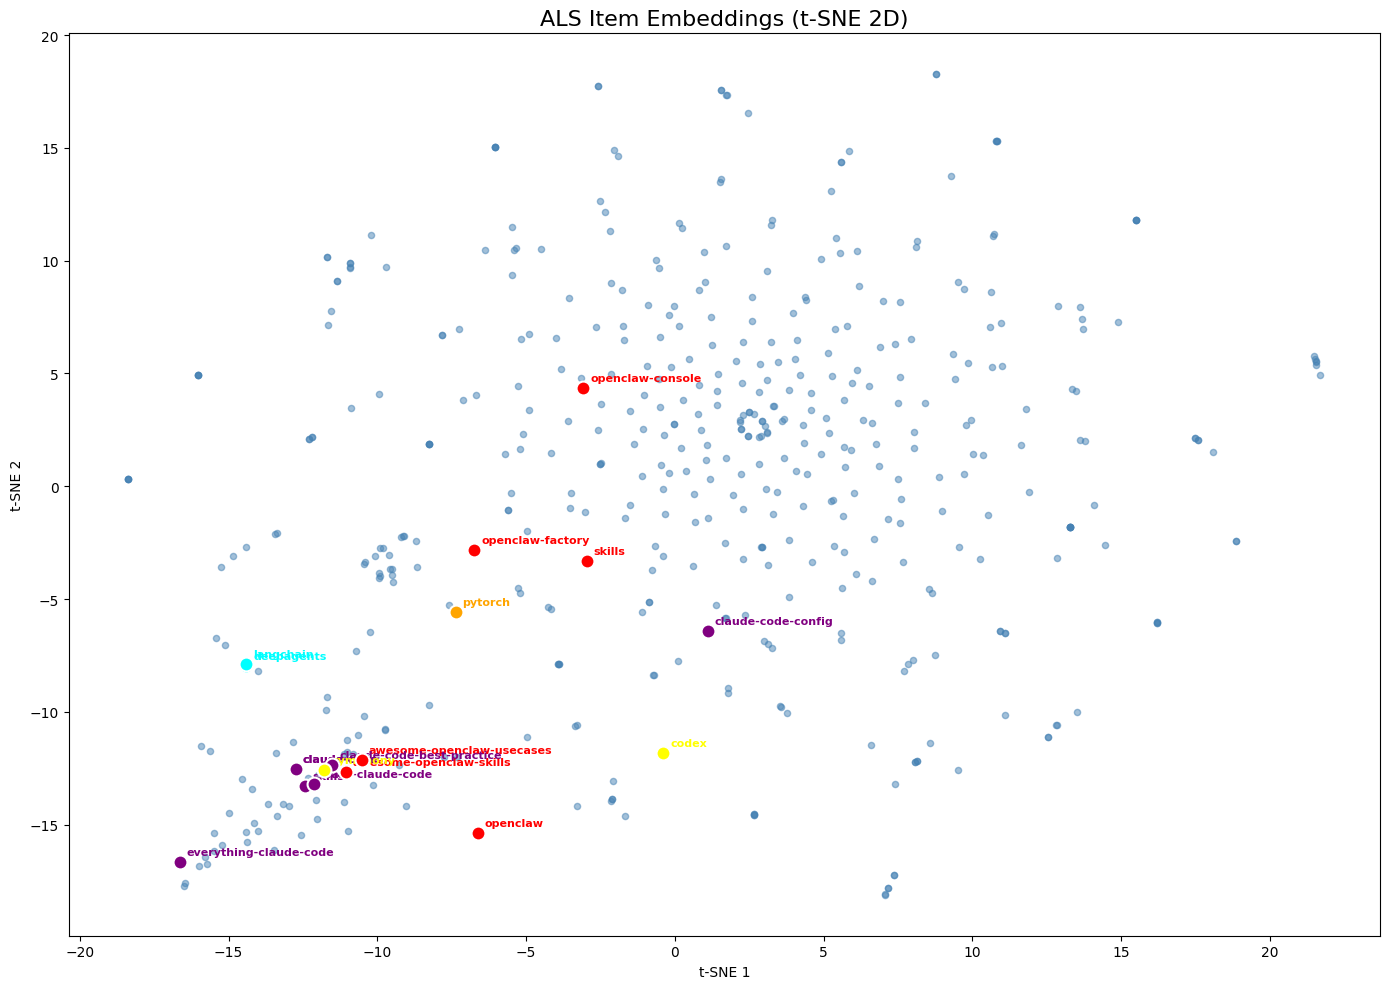

In [11]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 인기 상위 500개 repo의 임베딩
scores = popularity_scores(df, WEIGHTS)
top_repo_ids = scores.head(500).index.tolist()
top_in_model = [rid for rid in top_repo_ids if rid in item2idx]

top_indices = [item2idx[rid] for rid in top_in_model]
top_vecs = model.item_factors[top_indices]
top_names = [name_map.get(rid, f"id:{rid}") for rid in top_in_model]

print(f"시각화 대상: {len(top_in_model)}개 repo")

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(top_vecs)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(coords[:, 0], coords[:, 1], s=20, alpha=0.5, c="steelblue")

# 관심 repo 하이라이트
highlight_keywords = ["openclaw", "pytorch", "tensorflow", "anthropic", "claude",
                       "darksword", "langchain", "openai", "llama"]
colors = ["red", "orange", "green", "purple", "purple",
          "magenta", "cyan", "yellow", "brown"]

for kw, color in zip(highlight_keywords, colors):
    for i, name in enumerate(top_names):
        if kw.lower() in name.lower():
            ax.scatter(coords[i, 0], coords[i, 1], s=100, c=color,
                      edgecolors="white", linewidth=1.5, zorder=5)
            ax.annotate(name.split("/")[-1], (coords[i, 0], coords[i, 1]),
                       textcoords="offset points", xytext=(5, 5),
                       fontsize=8, color=color, fontweight="bold")

ax.set_title("ALS Item Embeddings (t-SNE 2D)", fontsize=16)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## 5. 케이스 스터디: DarkSword

2026년 3월 21~23일에 공개된 iOS 익스플로잇 체인 **DarkSword**.

- `htimesnine/DarkSword-RCE` (3/21) — WebKit RCE 원본
- `ghh-jb/DarkSword` (3/22) — 익스플로잇 체인 풀 덤프
- `opa334/darksword-kexploit` (3/23) — 커널 익스플로잇 Obj-C 재구현 (~1000 stars)

GitHub Archive 이벤트로 이 사건의 반응을 추적합니다.

In [12]:
# DarkSword 관련 repo 찾기
darksword_repos = {
    rid: name for rid, name in name_map.items()
    if "darksword" in name.lower() or "dark-sword" in name.lower()
}

if not darksword_repos:
    # BigQuery에서 직접 검색
    ds_query = f"""
    SELECT DISTINCT repo.id AS repo_id, repo.name AS repo_name
    FROM `githubarchive.day.{latest_date}`
    WHERE LOWER(repo.name) LIKE '%darksword%'
       OR LOWER(repo.name) LIKE '%dark-sword%'
    """
    ds_df = client.query(ds_query).to_dataframe()
    darksword_repos = dict(zip(ds_df["repo_id"], ds_df["repo_name"]))

print(f"DarkSword 관련 repo {len(darksword_repos)}개:")
for rid, name in sorted(darksword_repos.items(), key=lambda x: x[1]):
    print(f"  {rid}: {name}")

DarkSword 관련 repo 13개:
  1164285958: Darksword333/ilu3-ocaml
  1192598633: Explorer1092/darksword-kexploit
  1192020604: RRR3d/DarkSword
  974201947: TheDarkSword/DarkClient
  1193101253: W1xced-io/darksword-kexploit
  1193852897: adriyansyah-mf/DarkSword-RCE
  1189801315: bhideki/darksword
  1191747199: d34d633f/darksword-kexploit
  1188933103: ghh-jb/DarkSword
  1188206037: htimesnine/DarkSword-RCE
  1194356422: ndndndn1/DarkSword-RCE
  1189540594: opa334/darksword-kexploit
  1190592671: wh1te4ever/darksword-kexploit-fun


In [13]:
# DarkSword 주요 repo (BigQuery에서 확인한 ID)
DS_MAIN = {
    1188206037: "htimesnine/DarkSword-RCE",
    1188933103: "ghh-jb/DarkSword",
    1189540594: "opa334/darksword-kexploit",
}

# 전체 DarkSword repo ID (darksword_repos에서)
ds_repo_ids = set(darksword_repos.keys()) | set(DS_MAIN.keys())

# 전체 기간에서 이벤트 필터 (샘플링 안 된 전체 데이터 사용)
full_df = load_period(OUTPUT_DIR, date(2026, 3, 19), TRAIN_END)
ds_events = full_df[full_df["repo_id"].isin(ds_repo_ids)].copy()

if len(ds_events) == 0:
    print("DarkSword 이벤트가 현재 데이터 범위에 없습니다.")
    print(f"데이터 범위: 2026-03-19 ~ {TRAIN_END}")
else:
    print(f"DarkSword 이벤트: {len(ds_events):,} rows")
    print(f"\n이벤트 타입 분포:")
    print(ds_events.groupby("type")["cnt"].sum().sort_values(ascending=False))

DarkSword 이벤트: 256 rows

이벤트 타입 분포:
type
WatchEvent           166
ForkEvent             72
PushEvent             23
CreateEvent            2
IssueCommentEvent      2
PullRequestEvent       2
Name: cnt, dtype: Int32


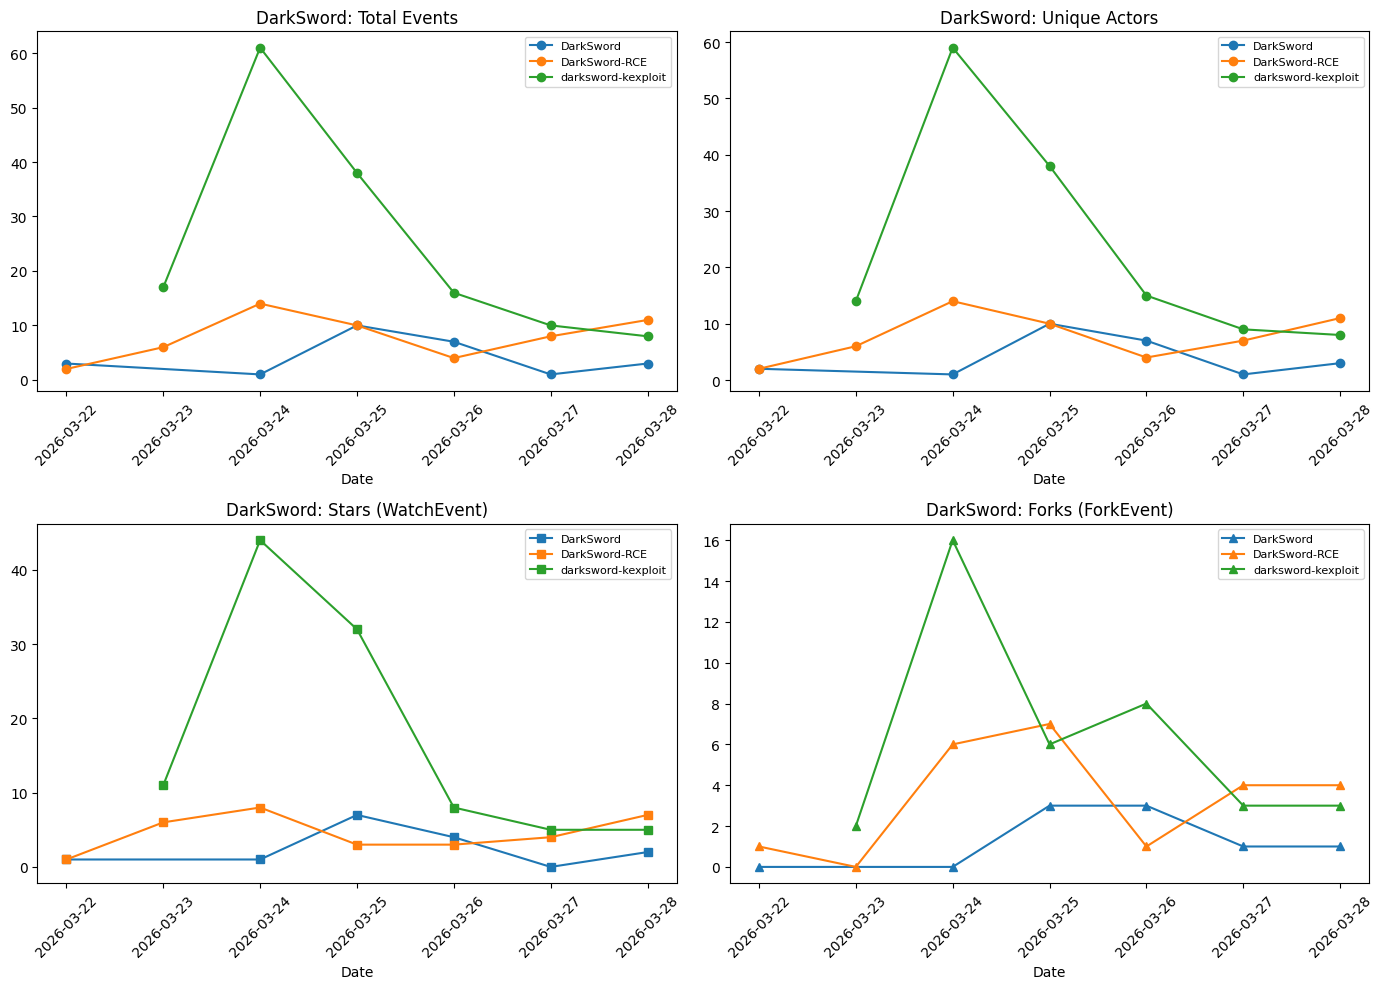


일별 상세:
               forks                                      stars                                  total_events                                 
repo       DarkSword DarkSword-RCE darksword-kexploit DarkSword DarkSword-RCE darksword-kexploit    DarkSword DarkSword-RCE darksword-kexploit
date                                                                                                                                          
2026-03-22       0.0           1.0                0.0       1.0           1.0                0.0          3.0           2.0                0.0
2026-03-23       0.0           0.0                2.0       0.0           6.0               11.0          0.0           6.0               17.0
2026-03-24       0.0           6.0               16.0       1.0           8.0               44.0          1.0          14.0               61.0
2026-03-25       3.0           7.0                6.0       7.0           3.0               32.0         10.0          10.0           

In [14]:
# 주요 3개 repo 일별 이벤트 추이
import matplotlib.pyplot as plt

daily_counts = []
for pf in sorted(OUTPUT_DIR.glob("*.parquet")):
    d = pf.stem
    if d < "20260319":
        continue
    day_df = pd.read_parquet(pf)
    for rid, name in DS_MAIN.items():
        repo_day = day_df[day_df["repo_id"] == rid]
        if len(repo_day) > 0:
            by_type = repo_day.groupby("type")["cnt"].sum()
            daily_counts.append({
                "date": d,
                "repo": name.split("/")[-1],
                "total_events": int(repo_day["cnt"].sum()),
                "unique_actors": repo_day["actor_id"].nunique(),
                "stars": int(by_type.get("WatchEvent", 0)),
                "forks": int(by_type.get("ForkEvent", 0)),
            })

daily_df = pd.DataFrame(daily_counts)
if len(daily_df) > 0:
    daily_df["date"] = pd.to_datetime(daily_df["date"])

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for name, group in daily_df.groupby("repo"):
        axes[0, 0].plot(group["date"], group["total_events"], marker="o", label=name)
        axes[0, 1].plot(group["date"], group["unique_actors"], marker="o", label=name)
        axes[1, 0].plot(group["date"], group["stars"], marker="s", label=name)
        axes[1, 1].plot(group["date"], group["forks"], marker="^", label=name)

    for ax, title in zip(axes.flat,
            ["Total Events", "Unique Actors", "Stars (WatchEvent)", "Forks (ForkEvent)"]):
        ax.set_title(f"DarkSword: {title}")
        ax.set_xlabel("Date")
        ax.legend(fontsize=8)
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    # 테이블로도 출력
    print("\n일별 상세:")
    pivot = daily_df.pivot_table(
        index="date", columns="repo",
        values=["total_events", "stars", "forks"], fill_value=0
    )
    print(pivot.to_string())
else:
    print("DarkSword 일별 이벤트 없음")

In [15]:
# DarkSword의 임베딩이 있다면 유사 레포 확인
for rid, name in darksword_repos.items():
    if rid in item2idx:
        print(f"\n{'='*60}")
        _ = find_similar_repos(name.split("/")[-1], name_map, item2idx, model, top_k=10)


🎯 Target: opa334/darksword-kexploit (id=1189540594)
   Embedding norm: 0.0080

   Top-10 유사 repo:
    1. (id:1169442123)                                    sim=0.9837
    2. (id:1069918282)                                    sim=0.9834
    3. (id:270910423)                                     sim=0.9788
    4. (id:1185254260)                                    sim=0.9786
    5. (id:1177432315)                                    sim=0.9769
    6. (id:1188456590)                                    sim=0.9763
    7. (id:1076050360)                                    sim=0.9751
    8. (id:559348325)                                     sim=0.9737
    9. (id:388507997)                                     sim=0.9719
   10. (id:1165736327)                                    sim=0.9711




🎯 Target: opa334/darksword-kexploit (id=1189540594)
   Embedding norm: 0.0080

   Top-10 유사 repo:
    1. (id:1169442123)                                    sim=0.9837
    2. (id:1069918282)                                    sim=0.9834
    3. (id:270910423)                                     sim=0.9788
    4. (id:1185254260)                                    sim=0.9786
    5. (id:1177432315)                                    sim=0.9769
    6. (id:1188456590)                                    sim=0.9763
    7. (id:1076050360)                                    sim=0.9751
    8. (id:559348325)                                     sim=0.9737
    9. (id:388507997)                                     sim=0.9719
   10. (id:1165736327)                                    sim=0.9711




🎯 Target: Darksword333/ilu3-ocaml (id=1164285958)
   Embedding norm: 0.0000

   Top-10 유사 repo:
    1. (id:1138541568)                                    sim=0.9985
    2. (id:1176676875)                                    sim=0.9981
    3. (id:1164703988)                                    sim=0.9981
    4. (id:1172792591)                                    sim=0.9981
    5. (id:1175183042)                                    sim=0.9980
    6. (id:1180155802)                                    sim=0.9980
    7. (id:1173198942)                                    sim=0.9979
    8. (id:1176324309)                                    sim=0.9979
    9. (id:1171520781)                                    sim=0.9978
   10. (id:1190293874)                                    sim=0.9977




🎯 Target: TheDarkSword/DarkClient (id=974201947)
   Embedding norm: 0.0001

   Top-10 유사 repo:
    1. (id:1068464498)                                    sim=0.9998
    2. (id:1136047389)                                    sim=0.9997
    3. (id:1113133379)                                    sim=0.9990
    4. (id:664670604)                                     sim=0.9989
    5. (id:1175622098)                                    sim=0.9989
    6. (id:506667111)                                     sim=0.9987
    7. (id:1170904262)                                    sim=0.9983
    8. (id:1095099482)                                    sim=0.9975
    9. (id:1162498566)                                    sim=0.9974
   10. (id:1092774072)                                    sim=0.9971




🎯 Target: ndndndn1/DarkSword-RCE (id=1194356422)
   Embedding norm: 0.0000

   Top-10 유사 repo:
    1. (id:1142391516)                                    sim=0.9997
    2. (id:1092080869)                                    sim=0.9996
    3. (id:1142260930)                                    sim=0.9996
    4. (id:1190318133)                                    sim=0.9995
    5. (id:1170962978)                                    sim=0.9995
    6. (id:1062600658)                                    sim=0.9995
    7. (id:510466870)                                     sim=0.9994
    8. (id:648431291)                                     sim=0.9994
    9. (id:1151313167)                                    sim=0.9994
   10. (id:1131581776)                                    sim=0.9994



...


🎯 Target: ndndndn1/DarkSword-RCE (id=1194356422)
   Embedding norm: 0.0000

   Top-10 유사 repo:
    1. (id:1142391516)                                    sim=0.9997
    2. (id:1092080869)                                    sim=0.9996
    3. (id:1142260930)                                    sim=0.9996
    4. (id:1190318133)                                    sim=0.9995
    5. (id:1170962978)                                    sim=0.9995
    6. (id:1062600658)                                    sim=0.9995
    7. (id:510466870)                                     sim=0.9994
    8. (id:648431291)                                     sim=0.9994
    9. (id:1151313167)                                    sim=0.9994
   10. (id:1131581776)                                    sim=0.9994




🎯 Target: ndndndn1/DarkSword-RCE (id=1194356422)
   Embedding norm: 0.0000

   Top-10 유사 repo:
    1. (id:1142391516)                                    sim=0.9997
    2. (id:1092080869)                                    sim=0.9996
    3. (id:1142260930)                                    sim=0.9996
    4. (id:1190318133)                                    sim=0.9995
    5. (id:1170962978)                                    sim=0.9995
    6. (id:1062600658)                                    sim=0.9995
    7. (id:510466870)                                     sim=0.9994
    8. (id:648431291)                                     sim=0.9994
    9. (id:1151313167)                                    sim=0.9994
   10. (id:1131581776)                                    sim=0.9994




🎯 Target: opa334/darksword-kexploit (id=1189540594)
   Embedding norm: 0.0080

   Top-10 유사 repo:
    1. (id:1169442123)                                    sim=0.9837
    2. (id:1069918282)                                    sim=0.9834
    3. (id:270910423)                                     sim=0.9788
    4. (id:1185254260)                                    sim=0.9786
    5. (id:1177432315)                                    sim=0.9769
    6. (id:1188456590)                                    sim=0.9763
    7. (id:1076050360)                                    sim=0.9751
    8. (id:559348325)                                     sim=0.9737
    9. (id:388507997)                                     sim=0.9719
   10. (id:1165736327)                                    sim=0.9711




🎯 Target: opa334/darksword-kexploit (id=1189540594)
   Embedding norm: 0.0080

   Top-10 유사 repo:
    1. (id:1169442123)                                    sim=0.9837
    2. (id:1069918282)                                    sim=0.9834
    3. (id:270910423)                                     sim=0.9788
    4. (id:1185254260)                                    sim=0.9786
    5. (id:1177432315)                                    sim=0.9769
    6. (id:1188456590)                                    sim=0.9763
    7. (id:1076050360)                                    sim=0.9751
    8. (id:559348325)                                     sim=0.9737
    9. (id:388507997)                                     sim=0.9719
   10. (id:1165736327)                                    sim=0.9711




🎯 Target: RRR3d/DarkSword (id=1192020604)
   Embedding norm: 0.0002

   Top-10 유사 repo:
    1. (id:184648845)                                     sim=1.0000
    2. (id:1174902424)                                    sim=1.0000
    3. (id:1186696612)                                    sim=0.9322
    4. (id:1181807889)                                    sim=0.9313
    5. (id:1166721327)                                    sim=0.9309
    6. (id:1183640449)                                    sim=0.9299
    7. (id:1182865815)                                    sim=0.9294
    8. (id:1163775222)                                    sim=0.9292
    9. (id:1194188964)                                    sim=0.9291
   10. (id:1194274010)                                    sim=0.9290


In [16]:
# DarkSword에 반응한 유저들의 다른 관심사
if len(ds_events) > 0:
    ds_actors = set(ds_events["actor_id"].unique())
    print(f"DarkSword 관련 활동 유저: {len(ds_actors):,}명")

    # 이 유저들이 DarkSword 외에 가장 많이 활동한 repo
    actor_other = full_df[
        full_df["actor_id"].isin(ds_actors) &
        ~full_df["repo_id"].isin(ds_repo_ids)
    ]
    other_repos = actor_other.groupby("repo_id")["cnt"].sum().nlargest(20)

    # 이름 매핑
    other_ids = other_repos.index.tolist()
    ids_str = ", ".join(str(r) for r in other_ids)
    other_names_query = f"""
    SELECT DISTINCT repo.id AS repo_id, repo.name AS repo_name
    FROM `githubarchive.day.{latest_date}`
    WHERE repo.id IN ({ids_str})
    """
    other_names_df = client.query(other_names_query).to_dataframe()
    other_name_map = dict(zip(other_names_df["repo_id"], other_names_df["repo_name"]))

    print(f"\nDarkSword 유저들이 가장 많이 활동한 다른 repo Top-20:")
    for rid, cnt in other_repos.items():
        name = other_name_map.get(rid, f"(id:{rid})")
        print(f"  {name:<50s} events={cnt:,}")

DarkSword 관련 활동 유저: 229명



DarkSword 유저들이 가장 많이 활동한 다른 repo Top-20:
  imide/nixpkgs                                      events=62
  (id:1019145430)                                    events=53
  zing518/socks5_list                                events=52
  hc990275/NoMoreWalls                               events=52
  Mu-L/GitHub520                                     events=51
  1sLand99/vscode                                    events=51
  justinlietz93/openclaw                             events=51
  jing5460/Free-servers                              events=50
  zhengkaiyuan1993/dotnet-runtime                    events=50
  null101001/vscode                                  events=50
  HSL9412/TrendRadar                                 events=50
  edisplay/clawdbot                                  events=50
  bhardwajRahul/clawdbot                             events=50
  IrvanFza/clawdbot                                  events=50
  OnlyFor/moltbot                                    events=50
  lifeshadow/

## 6. BPR vs ALS

BPR(Bayesian Personalized Ranking)은 pairwise 학습 — "들은 곡 > 안 들은 곡" 순서를 최적화합니다.  
implicit 라이브러리에서 ALS와 동일한 인터페이스로 사용 가능합니다.

In [17]:
from implicit.bpr import BayesianPersonalizedRanking

BPR_PATH = MODEL_DIR / f"bpr_{latest_date}.pkl"

if BPR_PATH.exists():
    print(f"저장된 BPR 모델 로드: {BPR_PATH.name}")
    bpr_model = pickle.loads(BPR_PATH.read_bytes())
else:
    print("BPR 학습 시작...")
    t0 = time.time()
    bpr_model = BayesianPersonalizedRanking(
        factors=64, learning_rate=0.01, regularization=0.01,
        iterations=100, random_state=42,
    )
    bpr_model.fit(train_sparse)
    t_bpr = time.time() - t0
    print(f"BPR 학습 완료: {t_bpr:.1f}s")

    BPR_PATH.write_bytes(pickle.dumps(bpr_model))
    print(f"모델 저장: {BPR_PATH.name} ({BPR_PATH.stat().st_size / 1024**2:.0f}MB)")

print(f"Item factors: {bpr_model.item_factors.shape}")
print(f"User factors: {bpr_model.user_factors.shape}")

BPR 학습 시작...


  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:02<03:49,  2.32s/it]

  1%|          | 1/100 [00:02<03:49,  2.32s/it, train_auc=50.03%, skipped=0.55%]

  2%|▏         | 2/100 [00:04<03:28,  2.12s/it, train_auc=50.03%, skipped=0.55%]

...

100%|██████████| 100/100 [03:46<00:00,  1.97s/it, train_auc=74.61%, skipped=0.55%]

100%|██████████| 100/100 [03:46<00:00,  1.97s/it, train_auc=74.70%, skipped=0.54%]

100%|██████████| 100/100 [03:46<00:00,  2.27s/it, train_auc=74.70%, skipped=0.54%]

BPR 학습 완료: 237.0s


모델 저장: bpr_20260328.pkl (3563MB)
Item factors: (8856268, 65)
User factors: (5511853, 65)


In [18]:
# ALS vs BPR 임베딩 비교 — 같은 repo에 대해 유사 repo가 다른가?
print("=== ALS: openclaw 유사 repo ===")
_ = find_similar_repos("openclaw/openclaw", name_map, item2idx, model, top_k=10)

print("\n=== BPR: openclaw 유사 repo ===")
_ = find_similar_repos("openclaw/openclaw", name_map, item2idx, bpr_model, top_k=10)

=== ALS: openclaw 유사 repo ===



🎯 Target: openclaw/openclaw (id=1103012935)
   Embedding norm: 11.9508

   Top-10 유사 repo:
    1. (id:480099482)                                     sim=0.9988
    2. (id:1175902813)                                    sim=0.9987
    3. (id:1175295617)                                    sim=0.9987
    4. (id:1172471873)                                    sim=0.9985
    5. (id:1171571130)                                    sim=0.9984
    6. (id:1183062937)                                    sim=0.9984
    7. (id:1156599839)                                    sim=0.9984
    8. (id:1173741740)                                    sim=0.9984
    9. (id:1168862148)                                    sim=0.9984
   10. (id:1022707536)                                    sim=0.9984

=== BPR: openclaw 유사 repo ===



🎯 Target: openclaw/openclaw (id=1103012935)
   Embedding norm: 3.8233

   Top-10 유사 repo:
    1. (id:1073224795)                                    sim=0.9953
    2. (id:1086122599)                                    sim=0.9952
    3. (id:1141838987)                                    sim=0.9952
    4. (id:924106301)                                     sim=0.9950
    5. affaan-m/everything-claude-code                    sim=0.9949
    6. (id:1141375692)                                    sim=0.9948
    7. (id:1176855074)                                    sim=0.9947
    8. (id:1152536742)                                    sim=0.9947
    9. (id:1169199358)                                    sim=0.9947
   10. (id:75325926)                                      sim=0.9946


## 7. 케이스 스터디: 급상승 repo 분석

3월 후반에 급상승한 repo들을 분석합니다.

| repo | 변화 | 포인트 |
|------|------|--------|
| `vueup/vue-quill` | 6 → 28,615 (x3920) | 봇? 진짜 바이럴? |
| `open-jarvis/OpenJarvis` | AI 어시스턴트 | 트렌드 분석 |

각 케이스에서 **"이 repo에 관심 있는 유저가 다른 뭘 했는지"** → 연관 추천으로 이어집니다.

vue-quill 이벤트: 470 rows

이벤트 타입 분포:
type
IssuesEvent          57212
WatchEvent               3
PullRequestEvent         2
CreateEvent              1
IssueCommentEvent        1
Name: cnt, dtype: Int32

유저 수: 328
유저당 이벤트 통계:
count         328.0
mean     174.448171
std      333.565444
min             1.0
25%             3.0
50%             7.0
75%          177.25
max          1547.0
Name: cnt, dtype: Float64

상위 10 유저 (봇 후보?):
  actor_id=257756598: events=1547
  actor_id=257756158: events=1494
  actor_id=257757316: events=1486
  actor_id=257756837: events=1475
  actor_id=257756812: events=1462
  actor_id=257757251: events=1414
  actor_id=257757672: events=1329
  actor_id=257757231: events=1320
  actor_id=257756805: events=1314
  actor_id=257757420: events=1280


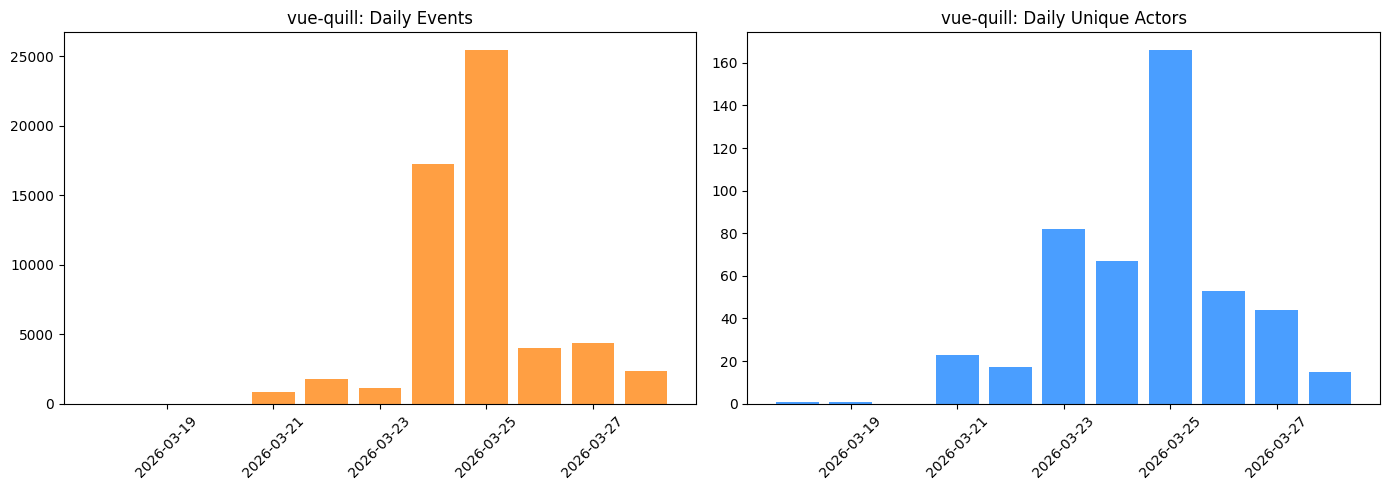

In [19]:
# vue-quill: x3920 급등 — 봇인지 진짜인지?
full_df = load_period(OUTPUT_DIR, date(2026, 3, 15), TRAIN_END)

# vue-quill repo id 찾기
vq_query = f"""
SELECT DISTINCT repo.id AS repo_id, repo.name AS repo_name
FROM `githubarchive.day.{latest_date}`
WHERE LOWER(repo.name) LIKE '%vue-quill%'
"""
vq_df = client.query(vq_query).to_dataframe()
vq_map = dict(zip(vq_df["repo_id"], vq_df["repo_name"]))
vq_ids = set(vq_map.keys())

vq_events = full_df[full_df["repo_id"].isin(vq_ids)]
print(f"vue-quill 이벤트: {len(vq_events):,} rows")

if len(vq_events) > 0:
    print(f"\n이벤트 타입 분포:")
    print(vq_events.groupby("type")["cnt"].sum().sort_values(ascending=False))

    # 봇 탐지: 유저당 이벤트 수 분포
    actor_counts = vq_events.groupby("actor_id")["cnt"].sum()
    print(f"\n유저 수: {len(actor_counts):,}")
    print(f"유저당 이벤트 통계:")
    print(actor_counts.describe())
    print(f"\n상위 10 유저 (봇 후보?):")
    for uid, cnt in actor_counts.nlargest(10).items():
        print(f"  actor_id={uid}: events={cnt}")

    # 일별 추이
    vq_daily = []
    for pf in sorted(OUTPUT_DIR.glob("*.parquet")):
        d = pf.stem
        if d < "20260315":
            continue
        day_df = pd.read_parquet(pf)
        rd = day_df[day_df["repo_id"].isin(vq_ids)]
        if len(rd) > 0:
            vq_daily.append({
                "date": d, "events": int(rd["cnt"].sum()),
                "actors": rd["actor_id"].nunique()
            })

    vq_daily_df = pd.DataFrame(vq_daily)
    vq_daily_df["date"] = pd.to_datetime(vq_daily_df["date"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(vq_daily_df["date"], vq_daily_df["events"], color="#ff9f43")
    axes[0].set_title("vue-quill: Daily Events")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(vq_daily_df["date"], vq_daily_df["actors"], color="#4a9eff")
    axes[1].set_title("vue-quill: Daily Unique Actors")
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

In [20]:
# OpenJarvis: AI 어시스턴트 트렌드
oj_query = f"""
SELECT DISTINCT repo.id AS repo_id, repo.name AS repo_name
FROM `githubarchive.day.{latest_date}`
WHERE LOWER(repo.name) LIKE '%jarvis%'
"""
oj_df = client.query(oj_query).to_dataframe()
oj_map = dict(zip(oj_df["repo_id"], oj_df["repo_name"]))
oj_ids = set(oj_map.keys())

oj_events = full_df[full_df["repo_id"].isin(oj_ids)]
print(f"Jarvis 관련 이벤트: {len(oj_events):,} rows")
print(f"관련 repo: {len(oj_ids)}개, 활동 유저: {oj_events['actor_id'].nunique():,}명")

# 인기 Top-5 jarvis repo
oj_scores = oj_events.groupby("repo_id")["cnt"].sum().nlargest(5)
print(f"\nJarvis Top-5:")
for rid, cnt in oj_scores.items():
    print(f"  {oj_map.get(rid, str(rid)):<45s} events={cnt:,}")

Jarvis 관련 이벤트: 2,191 rows
관련 repo: 319개, 활동 유저: 749명

Jarvis Top-5:
  thevickypedia/JarvisMonitor                   events=571
  open-jarvis/OpenJarvis                        events=498
  Turbo31150/jarvis-linux                       events=353
  jarvis-aux/jarvis-dashboard                   events=269
  drussell23/JARVIS                             events=244


## 8. 연관 추천: "이 repo를 Star한 사람은 이것도 좋아합니다"

케이스 스터디에서 발견한 repo를 시작점으로,  
**임베딩 유사도** 기반 연관 추천을 만들어봅니다.

ALS/BPR 임베딩 → 코사인 유사도 → Top-K 유사 repo = **연관 추천**

In [21]:
# 연관 추천 함수
def related_repos(repo_query, model, name_map, item2idx, idx2item, top_k=10):
    """'이 repo를 Star한 사람은 이것도 좋아합니다' 연관 추천."""
    candidates = {
        rid: name for rid, name in name_map.items()
        if repo_query.lower() in name.lower() and rid in item2idx
    }
    if not candidates:
        print(f"'{repo_query}' not found in embeddings")
        return None

    target_rid = min(candidates, key=lambda r: len(candidates[r]))
    target_name = candidates[target_rid]
    target_vec = model.item_factors[item2idx[target_rid]].reshape(1, -1)

    sims = cosine_similarity(target_vec, model.item_factors)[0]
    top_indices = np.argsort(sims)[::-1][1:top_k + 1]

    print(f"\n💡 '{target_name}'을(를) Star한 사람은 이런 repo도 좋아합니다:")
    print(f"{'─' * 65}")
    results = []
    for i, idx in enumerate(top_indices, 1):
        rid = idx2item[idx]
        name = name_map.get(rid, f"(id:{rid})")
        sim = sims[idx]
        print(f"  {i:2d}. {name:<50s} ({sim:.4f})")
        results.append({"rank": i, "repo_name": name, "similarity": sim})

    return pd.DataFrame(results)


# DarkSword → 연관 추천 (보안 관련 repo가 나올까?)
print("=" * 65)
_ = related_repos("darksword-kexploit", model, name_map, item2idx, idx2item, top_k=10)

# OpenJarvis → 연관 추천 (AI 어시스턴트 관련?)
print("\n" + "=" * 65)
_ = related_repos("open-jarvis/OpenJarvis", model, name_map, item2idx, idx2item, top_k=10)

# vue-quill → 연관 추천 (프론트엔드? 봇과 같은 패턴?)
print("\n" + "=" * 65)
_ = related_repos("vue-quill", model, name_map, item2idx, idx2item, top_k=10)


💡 'opa334/darksword-kexploit'을(를) Star한 사람은 이런 repo도 좋아합니다:
─────────────────────────────────────────────────────────────────
   1. (id:1169442123)                                    (0.9837)
   2. (id:1069918282)                                    (0.9834)
   3. (id:270910423)                                     (0.9788)
   4. (id:1185254260)                                    (0.9786)
   5. (id:1177432315)                                    (0.9769)
   6. (id:1188456590)                                    (0.9763)
   7. (id:1076050360)                                    (0.9751)
   8. (id:559348325)                                     (0.9737)
   9. (id:388507997)                                     (0.9719)
  10. (id:1165736327)                                    (0.9711)




💡 'open-jarvis/OpenJarvis'을(를) Star한 사람은 이런 repo도 좋아합니다:
─────────────────────────────────────────────────────────────────
   1. (id:1180596322)                                    (0.9975)
   2. (id:1172305675)                                    (0.9973)
   3. (id:1082850008)                                    (0.9973)
   4. (id:1187584978)                                    (0.9966)
   5. (id:700051151)                                     (0.9966)
   6. (id:1129859709)                                    (0.9965)
   7. (id:1178401435)                                    (0.9965)
   8. (id:1185101895)                                    (0.9965)
   9. (id:789567149)                                     (0.9964)
  10. (id:1180783925)                                    (0.9962)




💡 'vueup/vue-quill'을(를) Star한 사람은 이런 repo도 좋아합니다:
─────────────────────────────────────────────────────────────────
   1. (id:1193534790)                                    (0.9993)
   2. (id:1193548187)                                    (0.9993)
   3. (id:1193546744)                                    (0.9993)
   4. (id:1191677935)                                    (0.9992)
   5. (id:1191712254)                                    (0.9992)
   6. (id:1192713915)                                    (0.9992)
   7. (id:1190574259)                                    (0.9992)
   8. (id:1192267551)                                    (0.9992)
   9. (id:1192267600)                                    (0.9992)
  10. (id:1192875527)                                    (0.9992)


## 9. 정리

**행렬분해 실습:**
- ALS: confidence 기반, 닫힌 해, 병렬화 쉬움 → 대규모 implicit feedback에 적합
- BPR: pairwise ranking, SGD 기반 → 순서가 중요한 추천에 적합
- 두 모델 모두 **임베딩(잠재 벡터)**를 학습 → 유사도 기반 연관 추천 가능

**케이스 스터디에서 배운 것:**
- **DarkSword**: 보안 이슈 → Star/Fork 폭증 후 빠른 감소 (바이럴 패턴)
- **vue-quill**: 비정상적 급등 → 봇 탐지 관점 (유저당 이벤트 분포 분석)
- **OpenJarvis**: AI 어시스턴트 트렌드 → 관련 생태계 파악

**연관 추천의 흐름:**
1. 유저-아이템 상호작용 행렬 구축
2. ALS/BPR로 임베딩 학습
3. 코사인 유사도로 "이 repo와 비슷한 repo" 검색
4. → **"이 repo를 Star한 사람은 이것도 좋아합니다"**